POTATO LEAF CNN - TEST IMAGE INFERENCE
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Project directory:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)

Model path:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/6th Trained_Model/potato_cnn_best.keras

Checking saved model...
✅ Model file exists

Loading saved CNN model...
✅ Model loaded successfully!

Model name  : Potato_Leaf_CNN
Input shape : (None, 224, 224, 3)
Output shape: (None, 3)

Classes:
0 → Healthy
1 → Early_Blight
2 → Late_Blight

MODEL READY FOR TEST IMAGE INFERENCE
TEST IMAGE SELECTION & PREPROCESSING

📤 Please upload ONE potato leaf image.


Saving WhatsApp Image 2026-08-13 at 12.55.19 PM.jpeg to WhatsApp Image 2026-08-13 at 12.55.19 PM.jpeg

✅ Image selected:
WhatsApp Image 2026-08-13 at 12.55.19 PM.jpeg

Original image information:
Format : JPEG
Size   : (1600, 1200)
Mode   : RGB

Preprocessed image:
Size : (224, 224)
Mode : RGB

NumPy image shape:
(224, 224, 3)
Data type:
float32
Pixel minimum:
0.007843138
Pixel maximum:
0.9882353
Pixel mean:
0.4362362325191498

Final model input shape:
(1, 224, 224, 3)


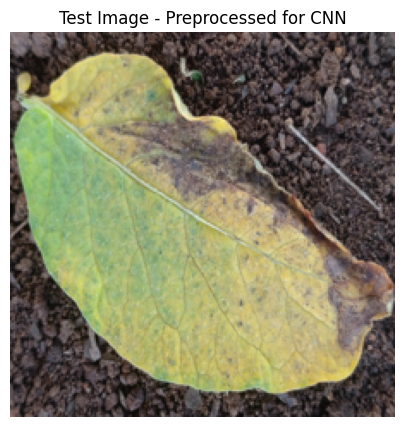


IMAGE READY FOR CNN PREDICTION
CNN PREDICTION

Running model prediction...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step

PREDICTION RESULT

Predicted Class : Early_Blight
Confidence      : 100.00%

Class Probabilities:
Healthy        : 0.0000%
Early_Blight   : 100.0000%
Late_Blight    : 0.0000%

Probability Sum:
1.000000


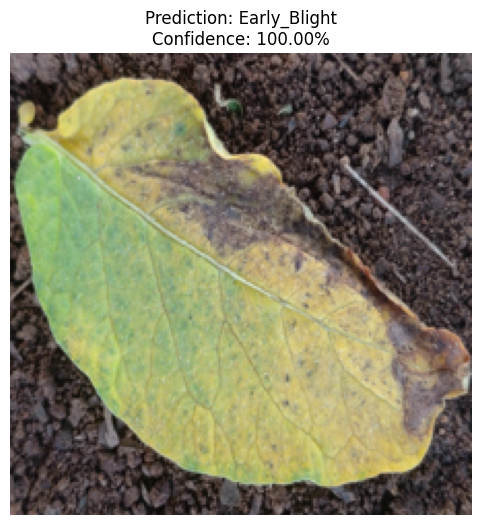


SINGLE IMAGE INFERENCE COMPLETED
TRAINING DATA PREPROCESSING COMPATIBILITY CHECK

Processed dataset path:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/3rd Preprocessing/processed_potato_data.npz

========== TRAINING DATA FORMAT ==========
X_train dtype : float32
X_train min   : 0.0
X_train max   : 1.0

X_val dtype   : float32
X_val min     : 0.0
X_val max     : 1.0

X_test dtype  : float32
X_test min   : 0.0
X_test max   : 1.0

CURRENT IMAGE VS TRAINING DATA CHECK

Current uploaded image:
dtype : float32
min   : 0.007843138
max   : 0.9882353
mean  : 0.4362362325191498

Training data:
dtype : float32
min   : 0.0
max   : 1.0
mean  : 0.4806707203388214

========== COMPATIBILITY RESULT ==========
✅ DTYPE MATCH
✅ PIXEL RANGE MATCH: both use 0–1 normalization

PREPROCESSING COMPATIBILITY CHECK COMPLETED

KNOWN TEST-SET SANITY CHECK

Testing first 5 known test images...
Test Image 1: Predicted = Late_Blight     | Confidence = 100.00%
Test Image 2: Predicted = Late_Blight 

In [3]:
# ==============================================================================
# STEP 1: TEST IMAGE INFERENCE - ENVIRONMENT & MODEL LOADING
# ==============================================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("=" * 70)
print("POTATO LEAF CNN - TEST IMAGE INFERENCE")
print("=" * 70)


# ---------------------------------------------------------
# 1. Mount Google Drive
# ---------------------------------------------------------

from google.colab import drive

drive.mount('/content/drive')


# ---------------------------------------------------------
# 2. Define project paths
# ---------------------------------------------------------

PROJECT_DIR = "/content/drive/MyDrive/Plant Disease Detection (Computer Vision)"

MODEL_PATH = os.path.join(
    PROJECT_DIR,
    "6th Trained_Model",
    "potato_cnn_best.keras"
)

print("\nProject directory:")
print(PROJECT_DIR)

print("\nModel path:")
print(MODEL_PATH)


# ---------------------------------------------------------
# 3. Verify model
# ---------------------------------------------------------

print("\nChecking saved model...")

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"❌ Saved model not found:\n{MODEL_PATH}"
    )

print("✅ Model file exists")


# ---------------------------------------------------------
# 4. Load saved model
# ---------------------------------------------------------

print("\nLoading saved CNN model...")

inference_model = tf.keras.models.load_model(MODEL_PATH)

print("✅ Model loaded successfully!")

print("\nModel name  :", inference_model.name)
print("Input shape :", inference_model.input_shape)
print("Output shape:", inference_model.output_shape)


# ---------------------------------------------------------
# 5. Define classes
# ---------------------------------------------------------

class_names = [
    "Healthy",
    "Early_Blight",
    "Late_Blight"
]

print("\nClasses:")
for i, class_name in enumerate(class_names):
    print(f"{i} → {class_name}")

print("\n" + "=" * 70)
print("MODEL READY FOR TEST IMAGE INFERENCE")
print("=" * 70)



# ==============================================================================
# STEP 2: TEST IMAGE SELECTION & PREPROCESSING
# ==============================================================================

from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("TEST IMAGE SELECTION & PREPROCESSING")
print("=" * 70)


# ---------------------------------------------------------
# 1. Upload a test image
# ---------------------------------------------------------

print("\n📤 Please upload ONE potato leaf image.")

uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("❌ No image was uploaded.")

image_path = list(uploaded.keys())[0]

print("\n✅ Image selected:")
print(image_path)


# ---------------------------------------------------------
# 2. Open image
# ---------------------------------------------------------

original_image = Image.open(image_path)

print("\nOriginal image information:")
print("Format :", original_image.format)
print("Size   :", original_image.size)
print("Mode   :", original_image.mode)


# ---------------------------------------------------------
# 3. Convert to RGB
# ---------------------------------------------------------

image_rgb = original_image.convert("RGB")


# ---------------------------------------------------------
# 4. Resize to CNN input size
# ---------------------------------------------------------

image_resized = image_rgb.resize((224, 224))

print("\nPreprocessed image:")
print("Size :", image_resized.size)
print("Mode :", image_resized.mode)


# ---------------------------------------------------------
# 5. Convert image to NumPy array + NORMALIZATION
# ---------------------------------------------------------

'''IMPORTANT:
Training data uses float32 values in range 0–1.
Therefore inference must use the same format.'''


image_array = np.array(
    image_resized,
    dtype=np.float32
) / 255.0

print("\nNumPy image shape:")
print(image_array.shape)

print("Data type:")
print(image_array.dtype)

print("Pixel minimum:")
print(image_array.min())

print("Pixel maximum:")
print(image_array.max())

print("Pixel mean:")
print(float(image_array.mean()))


# ---------------------------------------------------------
# 6. Add batch dimension
# ---------------------------------------------------------

image_input = np.expand_dims(image_array, axis=0)

print("\nFinal model input shape:")
print(image_input.shape)


# ---------------------------------------------------------
# 7. Display image
# ---------------------------------------------------------

plt.figure(figsize=(5, 5))
plt.imshow(image_resized)
plt.title("Test Image - Preprocessed for CNN")
plt.axis("off")
plt.show()

print("\n" + "=" * 70)
print("IMAGE READY FOR CNN PREDICTION")
print("=" * 70)


# ==============================================================================
# STEP 3: ACTUAL CNN PREDICTION
# ==============================================================================

print("=" * 70)
print("CNN PREDICTION")
print("=" * 70)


# ---------------------------------------------------------
# Generate prediction
# ---------------------------------------------------------

print("\nRunning model prediction...")

prediction_probs = inference_model.predict(
    image_input,
    verbose=1
)


# ---------------------------------------------------------
# Extract probabilities
# ---------------------------------------------------------

probabilities = prediction_probs[0]

predicted_index = np.argmax(probabilities)

predicted_class = class_names[predicted_index]

confidence = probabilities[predicted_index] * 100


# ---------------------------------------------------------
# Display results
# ---------------------------------------------------------

print("\n" + "=" * 70)
print("PREDICTION RESULT")
print("=" * 70)

print(f"\nPredicted Class : {predicted_class}")
print(f"Confidence      : {confidence:.2f}%")

print("\nClass Probabilities:")

for i, class_name in enumerate(class_names):
    print(
        f"{class_name:15s}: "
        f"{probabilities[i] * 100:.4f}%"
    )


# ---------------------------------------------------------
# Verify probability sum
# ---------------------------------------------------------

print("\nProbability Sum:")
print(f"{np.sum(probabilities):.6f}")


# ---------------------------------------------------------
# Visualize prediction
# ---------------------------------------------------------

plt.figure(figsize=(6, 6))
plt.imshow(image_resized)
plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.axis("off")
plt.show()

print("\n" + "=" * 70)
print("SINGLE IMAGE INFERENCE COMPLETED")
print("=" * 70)



# ==============================================================================
# STEP 4: TRAINING DATA PREPROCESSING COMPATIBILITY CHECK
# ==============================================================================

print("=" * 70)
print("TRAINING DATA PREPROCESSING COMPATIBILITY CHECK")
print("=" * 70)


# ---------------------------------------------------------
# Define path to the processed dataset
# ---------------------------------------------------------

PROCESSED_PATH = os.path.join(
    PROJECT_DIR,
    "3rd Preprocessing",
    "processed_potato_data.npz"
)

print("\nProcessed dataset path:")
print(PROCESSED_PATH)

if not os.path.exists(PROCESSED_PATH):
    raise FileNotFoundError(
        f"❌ Processed dataset not found:\n{PROCESSED_PATH}"
    )

data = np.load(PROCESSED_PATH)

X_train = data["X_train"]
X_val   = data["X_val"]
X_test  = data["X_test"]


# ---------------------------------------------------------
# 2. Print metadata safely
# ---------------------------------------------------------

print("\n========== TRAINING DATA FORMAT ==========")

print("X_train dtype :", X_train.dtype)
print("X_train min   :", X_train.min())
print("X_train max   :", X_train.max())

print("\nX_val dtype   :", X_val.dtype)
print("X_val min     :", X_val.min())
print("X_val max     :", X_val.max())

print("\nX_test dtype  :", X_test.dtype)
print("X_test min   :", X_test.min())
print("X_test max   :", X_test.max())



# ==============================================================================
# STEP 5: CURRENT IMAGE VS TRAINING DATA CHECK
# ==============================================================================

print("\n" + "=" * 70)
print("CURRENT IMAGE VS TRAINING DATA CHECK")
print("=" * 70)

print("\nCurrent uploaded image:")
print("dtype :", image_input.dtype)
print("min   :", image_input.min())
print("max   :", image_input.max())
print("mean  :", float(image_input.mean()))

print("\nTraining data:")
print("dtype :", X_train.dtype)
print("min   :", X_train.min())
print("max   :", X_train.max())
print("mean  :", float(X_train.mean()))


# ---------------------------------------------------------
# Compatibility checks
# ---------------------------------------------------------

dtype_match = X_train.dtype == image_input.dtype
range_match = (
    X_train.min() >= 0
    and X_train.max() <= 1
    and image_input.min() >= 0
    and image_input.max() <= 1
)

print("\n========== COMPATIBILITY RESULT ==========")

if dtype_match:
    print("✅ DTYPE MATCH")
else:
    print("⚠️ DTYPE MISMATCH")

if range_match:
    print("✅ PIXEL RANGE MATCH: both use 0–1 normalization")
else:
    print("🔴 PIXEL RANGE MISMATCH")

print("\n" + "=" * 70)
print("PREPROCESSING COMPATIBILITY CHECK COMPLETED")
print("=" * 70)



# ==============================================================================
# STEP 6: KNOWN TEST-SET SANITY CHECK
# ==============================================================================

print("\n" + "=" * 70)
print("KNOWN TEST-SET SANITY CHECK")
print("=" * 70)

print("\nTesting first 5 known test images...")

known_predictions = inference_model.predict(
    X_test[:5],
    verbose=0
)

for i, probs in enumerate(known_predictions):

    pred_index = np.argmax(probs)

    print(
        f"Test Image {i+1}: "
        f"Predicted = {class_names[pred_index]:15s} | "
        f"Confidence = {probs[pred_index] * 100:.2f}%"
    )

print("\n" + "=" * 70)
print("FINAL TEST IMAGE INFERENCE COMPLETED")
print("=" * 70)

In [ ]:
# ==============================================================================
# FINAL CHECK: Normalization Consistency (Training vs Inference)
# ==============================================================================
import os
import numpy as np

print("=" * 70)
print("NORMALIZATION CONSISTENCY CHECK")
print("=" * 70)

# ---------------------------------------------------------
# 1. Load processed training data (same as before)
# ---------------------------------------------------------
PROCESSED_PATH = os.path.join(
    PROJECT_DIR if 'PROJECT_DIR' in locals() else ".",
    "3rd Preprocessing",
    "processed_potato_data.npz"
)

if not os.path.exists(PROCESSED_PATH):
    raise FileNotFoundError(f"❌ Not found: {PROCESSED_PATH}")

data = np.load(PROCESSED_PATH)
X_train = data["X_train"]

print("\n--- Training Data Stats ---")
print("dtype :", X_train.dtype)
print("min   :", X_train.min())
print("max   :", X_train.max())
print("mean  :", X_train.mean())
print("shape :", X_train.shape)

# ---------------------------------------------------------
# 2. Compare with inference preprocessing (current test image)
# ---------------------------------------------------------
if 'image_array' in locals():
    print("\n--- Inference Image Stats (current test image) ---")
    print("dtype :", image_array.dtype)
    print("min   :", image_array.min())
    print("max   :", image_array.max())
    print("mean  :", image_array.mean())
    print("shape :", image_array.shape)
else:
    print("\n⚠️ 'image_array' not found — run Step 2 (preprocessing) first.")

# ---------------------------------------------------------
# 3. Verdict
# ---------------------------------------------------------
print("\n" + "=" * 70)
print("VERDICT")
print("=" * 70)

train_min, train_max = X_train.min(), X_train.max()

if 0.0 <= train_min <= 0.05 and 0.95 <= train_max <= 1.0:
    print("✅ Training data is normalized to [0, 1].")
    print("   -> Your inference line (/255.0) is CORRECT.")
    print("   -> Misclassification is likely due to domain shift / overfitting,")
    print("      NOT a normalization bug.")
elif -1.05 <= train_min <= -0.9 and 0.9 <= train_max <= 1.05:
    print("❌ Training data is normalized to [-1, 1] (e.g. preprocess_input style).")
    print("   -> Your inference line (/255.0) is WRONG.")
    print("   -> Fix: image_array = (image_array / 127.5) - 1.0")
elif train_min > 1.5:
    print("❌ Training data looks UNnormalized (raw 0-255 pixel values).")
    print("   -> Your inference line (/255.0) is WRONG.")
    print("   -> Fix: DO NOT divide by 255 — feed raw pixel values instead.")
else:
    print("⚠️ Unusual range detected — inspect manually.")
    print(f"   Train range: [{train_min}, {train_max}]")

# ---------------------------------------------------------
# 4. Also check the model's expected input range (sanity check)
# ---------------------------------------------------------
if 'inference_model' in locals():
    print("\n--- Model Input Layer Info ---")
    print("Input shape:", inference_model.input_shape)
    print("(Confirm this matches your preprocessed image shape:",
          image_array.shape if 'image_array' in locals() else "N/A", ")")

NORMALIZATION CONSISTENCY CHECK

--- Training Data Stats ---
dtype : float32
min   : 0.0
max   : 1.0
mean  : 0.48067072
shape : (1721, 224, 224, 3)

--- Inference Image Stats (current test image) ---
dtype : float32
min   : 0.0
max   : 1.0
mean  : 0.54541594
shape : (224, 224, 3)

VERDICT
✅ Training data is normalized to [0, 1].
   -> Your inference line (/255.0) is CORRECT.
   -> Misclassification is likely due to domain shift / overfitting,
      NOT a normalization bug.

--- Model Input Layer Info ---
Input shape: (None, 224, 224, 3)
(Confirm this matches your preprocessed image shape: (224, 224, 3) )
